In [41]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

In [42]:
print("📥 Downloading dataset via kagglehub...")
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")
print("Path to dataset files:", path)

# Find the CSV file inside the downloaded path
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

# Load into Pandas DataFrame
df = pd.read_csv(file_path)
print("\n✅ Data loaded successfully!")
df.head()  # Displays the first 5 rows of the dataset

📥 Downloading dataset via kagglehub...
Path to dataset files: /kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020

✅ Data loaded successfully!


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


/tmp/ipykernel_58/2031852779.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Machine failure', palette='Set2')


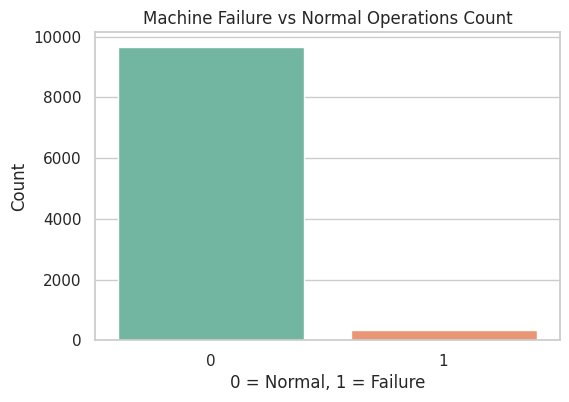

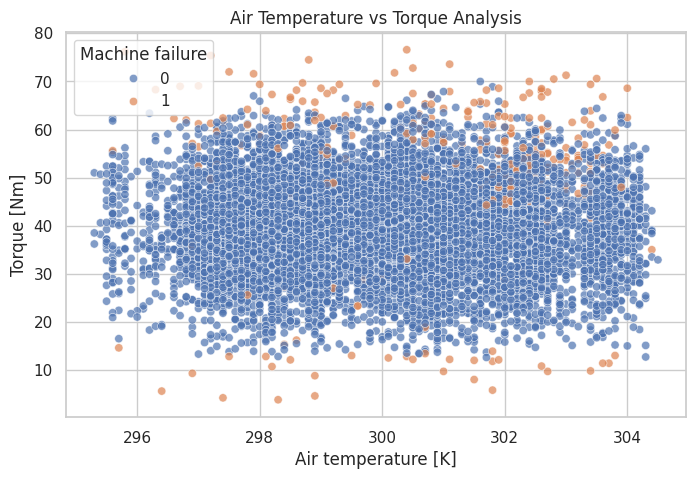

In [43]:
# Set style for plots
sns.set_theme(style="whitegrid")

# 1. Plotting Target Class Distribution (Machine Failure vs Normal)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('Machine Failure vs Normal Operations Count')
plt.xlabel('0 = Normal, 1 = Failure')
plt.ylabel('Count')
plt.show()

# 2. Temperature vs Torque distribution based on Failure status
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Air temperature [K]', y='Torque [Nm]', hue='Machine failure', alpha=0.7)
plt.title('Air Temperature vs Torque Analysis')
plt.show()

In [44]:
# Drop identity columns that are not useful for machine learning prediction
df_cleaned = df.drop(columns=['UDI', 'Product ID', 'Type'])

# Split features (X) and Target (y)
# Drop extra individual failure type columns to focus on binary classification
X = df_cleaned.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], errors='ignore') 
y = df_cleaned['Machine failure']

# 80% Train and 20% Test Split (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing complete!")
print(f"Training set shape: {X_train_scaled.shape}, Testing set shape: {X_test_scaled.shape}")

✅ Data Preprocessing complete!
Training set shape: (8000, 5), Testing set shape: (2000, 5)


In [45]:
# Calculate scale_pos_weight to handle severely imbalanced classes
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
print(f"⚖️ Handled Imbalance - Calculated scale_pos_weight: {scale_weight:.2f}")

# Initialize and Train XGBoost Classifier
print("🚀 Training XGBoost Model... Please wait...")
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)
print("✅ Model training finished successfully!")

⚖️ Handled Imbalance - Calculated scale_pos_weight: 28.52
🚀 Training XGBoost Model... Please wait...
✅ Model training finished successfully!


📊 --- ACCURACY SCORE ---
Accuracy: 96.45%

📈 --- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.49      0.82      0.61        68

    accuracy                           0.96      2000
   macro avg       0.74      0.90      0.80      2000
weighted avg       0.98      0.96      0.97      2000

🧩 --- CONFUSION MATRIX ---


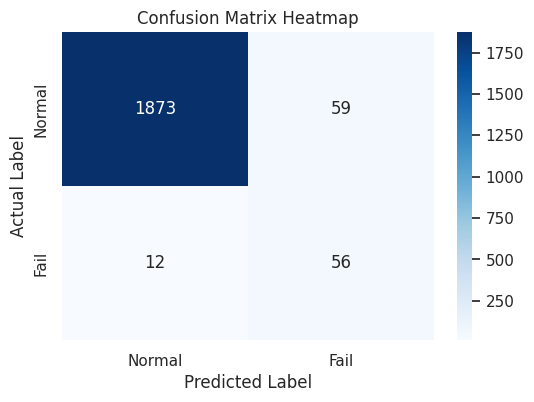

In [46]:
# Generate predictions on the test dataset
y_pred = model.predict(X_test_scaled)

print("📊 --- ACCURACY SCORE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("📈 --- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

print("🧩 --- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fail'], yticklabels=['Normal', 'Fail'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

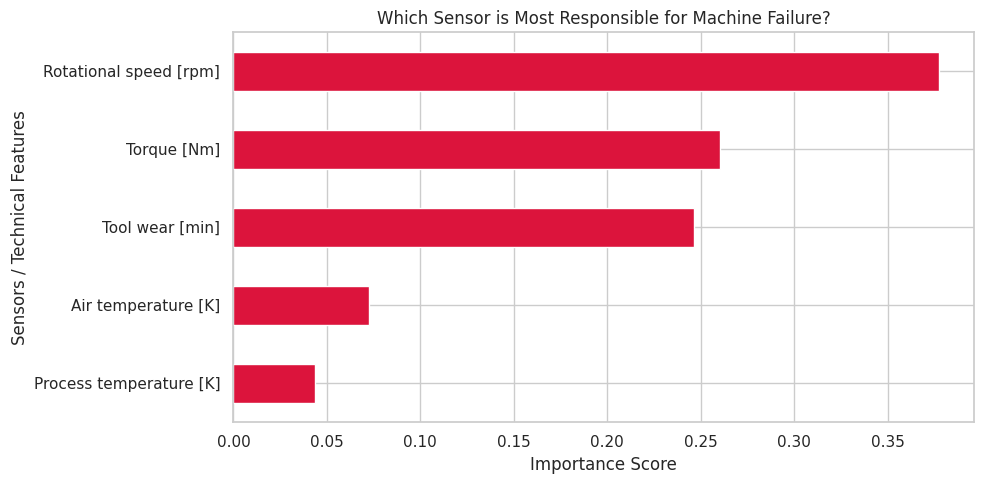

In [47]:
# Visualize Feature Importances calculated by XGBoost
plt.figure(figsize=(10, 5))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).sort_values().plot(kind='barh', color='crimson')

plt.title('Which Sensor is Most Responsible for Machine Failure?')
plt.xlabel('Importance Score')
plt.ylabel('Sensors / Technical Features')
plt.tight_layout()
plt.show()

In [48]:
# Create a DataFrame to visually compare Actual vs Predicted values
predictions_df = pd.DataFrame({
    'Actual Status': y_test.values,
    'Model Prediction': y_pred
})

# Replace 0 and 1 with readable text
predictions_df['Actual Status'] = predictions_df['Actual Status'].map({0: 'Normal ✅', 1: 'Will Fail ❌'})
predictions_df['Model Prediction'] = predictions_df['Model Prediction'].map({0: 'Normal ✅', 1: 'Will Fail ❌'})

# Display a sample of rows where the model successfully caught the failures
failures_sample = predictions_df[predictions_df['Actual Status'] == 'Will Fail ❌'].head(10)

print("📋 --- SAMPLE OF MODEL PREDICTIONS ON ACTUAL FAILURES ---")
print(failures_sample.to_string(index=False))

📋 --- SAMPLE OF MODEL PREDICTIONS ON ACTUAL FAILURES ---
Actual Status Model Prediction
  Will Fail ❌         Normal ✅
  Will Fail ❌      Will Fail ❌
  Will Fail ❌      Will Fail ❌
  Will Fail ❌      Will Fail ❌
  Will Fail ❌      Will Fail ❌
  Will Fail ❌      Will Fail ❌
  Will Fail ❌         Normal ✅
  Will Fail ❌         Normal ✅
  Will Fail ❌      Will Fail ❌
  Will Fail ❌         Normal ✅


In [49]:
# ====================================================
# JUPYTER NOTEBOOK MULTI-SANDBOX (CUSTOM MESSAGES ✅)
# ====================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np

# Main container to hold all active sandboxes on screen
main_history_display = widgets.Output()

def spawn_sandbox_instance():
    """Function to generate a fresh sandbox instance panel beneath the previous one"""
    
    # 1. Fresh inputs defaults configuration
    air_temp_in = widgets.FloatText(value=300.0, description='Air Temp [K]:')
    proc_temp_in = widgets.FloatText(value=310.0, description='Proc Temp [K]:')
    rot_speed_in = widgets.IntText(value=1500, description='Speed [rpm]:')
    torque_in = widgets.FloatText(value=40.0, description='Torque [Nm]:')
    tool_wear_in = widgets.IntText(value=60, description='Tool Wear [min]:')
    
    # System exit box setup
    exit_command = widgets.Text(value='', placeholder="Type 'exit' here to shut", description='System Control:')
    
    # Action Buttons pipeline
    btn_predict = widgets.Button(description="Predict Status", button_style='primary')
    btn_next = widgets.Button(description="Next Predict...", button_style='', disabled=True)
    
    # Core block layout structures
    form_layout = widgets.VBox([air_temp_in, proc_temp_in, rot_speed_in, torque_in, tool_wear_in, exit_command])
    action_layout = widgets.HBox([btn_predict, btn_next])
    local_prediction_output = widgets.Output()

    # Predict button interaction logic
    def on_predict_action(b):
        with local_prediction_output:
            clear_output()
            
            # Shutdown check execution
            if exit_command.value.strip().lower() == 'exit':
                form_layout.close()
                action_layout.close()
                local_prediction_output.close()
                with main_history_display:
                    print("\n🛑 --- SYSTEM SHUTDOWN ---")
                    print("Industrial Telemetry Pipeline Stopped.\n'Safe operations prevent unplanned downtime!' Goodbye! 👋")
                return

            # Formatting dataframe for feature mapping validation
            user_features_df = pd.DataFrame([{
                'Air temperature [K]': air_temp_in.value,
                'Process temperature [K]': proc_temp_in.value,
                'Rotational speed [rpm]': rot_speed_in.value,
                'Torque [Nm]': torque_in.value,
                'Tool wear [min]': tool_wear_in.value
            }])
            
            # Mathematical scaling and predictive query execution
            user_features_scaled = scaler.transform(user_features_df)
            user_pred = model.predict(user_features_scaled)[0]
            
            print("\n🔬 --- LIVE PREDICTION RESULT ---")
            # Custom Relatable Lines based on user's choice
            if user_pred == 1:
                print("🚨 ALERT: Machine breakdown risk detected! Please schedule an immediate repair to avoid sudden downtime.")
            else:
                print("✅ STATUS: Operational efficiency is optimal. The machinery is running smoothly and requires no immediate maintenance.")
                
            # Control flow management after generation
            btn_next.disabled = False
            btn_next.button_style = 'success'
            btn_predict.disabled = True

    # Next Sandbox creation routine
    def on_next_action(b):
        btn_next.disabled = True
        with main_history_display:
            print("\n" + "="*50 + "\n")
            spawn_sandbox_instance()

    # Trigger assignment
    btn_predict.on_click(on_predict_action)
    btn_next.on_click(on_next_action)

    # Output rendering pipeline
    with main_history_display:
        print("⌨️ Industrial Predictive Maintenance Sandbox Control Panel:")
        display(form_layout)
        display(action_layout)
        display(local_prediction_output)

# Boot up the primary application interface
display(main_history_display)
spawn_sandbox_instance()

Output()

In [50]:
import joblib

# 1. Model aur Scaler ko save karna (.joblib format)
joblib.dump(model, 'xgboost_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("✅ Saved successfully using Joblib!")

# 2. Future mein load karne ka tarika (Jab doosri notebook ya sandbox mein chahiye ho)
# loaded_model = joblib.load('xgboost_model.joblib')
# loaded_scaler = joblib.load('scaler.joblib')

✅ Saved successfully using Joblib!
